In [2]:
import sys
!{sys.executable} -m pip install scipy scikit-learn

  Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl (37.3 MB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --------------------------------------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv("SampleSuperstore_Cleaned.csv")
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9976 entries, 0 to 9975
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9976 non-null   str    
 1   Segment       9976 non-null   str    
 2   Country       9976 non-null   str    
 3   City          9976 non-null   str    
 4   State         9976 non-null   str    
 5   Postal Code   9976 non-null   int64  
 6   Region        9976 non-null   str    
 7   Category      9976 non-null   str    
 8   Sub-Category  9976 non-null   str    
 9   Sales         9976 non-null   float64
 10  Quantity      9976 non-null   int64  
 11  Discount      9976 non-null   float64
 12  Profit        9976 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1013.3 KB


In [5]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9976.000000,9976.000000,9976.000000,9976.000000,9976.000000
mean,55151.202285,230.147597,3.790898,0.156294,28.685693
std,32057.671463,623.752659,2.226696,0.206460,234.469173
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.295000,2.000000,0.000000,1.725850
50%,55901.000000,54.804000,3.000000,0.200000,8.666500
75%,90008.000000,209.970000,5.000000,0.200000,29.366000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
print("Mean Sales:", df["Sales"].mean())
print("Median Sales:", df["Sales"].median())
print("Standard Deviation:", df["Sales"].std())

Mean Sales: 230.14759726343226
Median Sales: 54.804
Standard Deviation: 623.7526588239451


In [7]:
print("Sales Skewness:", df["Sales"].skew())

Sales Skewness: 12.963127949520269


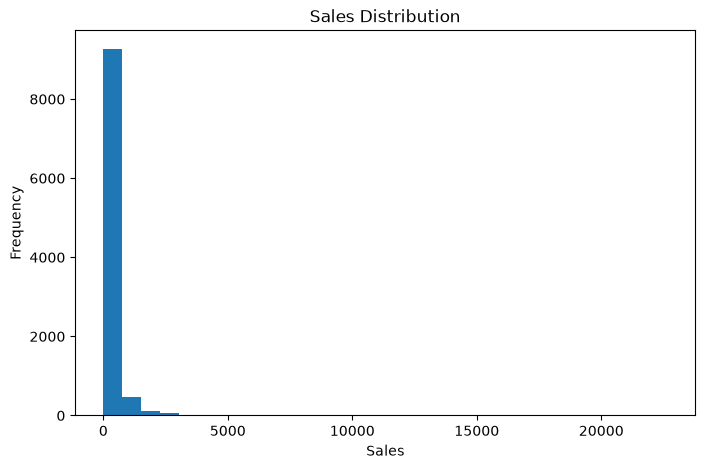

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

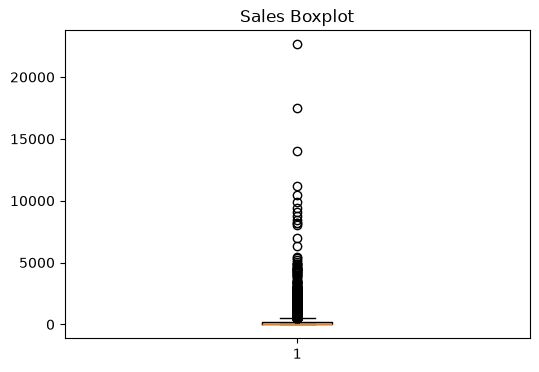

In [9]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Sales"])
plt.title("Sales Boxplot")
plt.show()

In [10]:
consumer = df[df["Segment"]=="Consumer"]["Sales"]
corporate = df[df["Segment"]=="Corporate"]["Sales"]

t_stat, p_value = stats.ttest_ind(consumer, corporate)

print("T-Statistic =", t_stat)
print("P-Value =", p_value)

T-Statistic = -0.7548395448518997
P-Value = 0.450366954652518


In [11]:
if p_value < 0.05:
    print("Consumer and Corporate sales are significantly different.")
else:
    print("No significant difference between Consumer and Corporate sales.")

No significant difference between Consumer and Corporate sales.


In [12]:
cluster_data = df[["Sales","Profit"]]
cluster_data.head()

,Sales,Profit
0,261.9600,41.9136
1,731.9400,219.5820
2,14.6200,6.8714
3,957.5775,-383.0310
4,22.3680,2.5164


In [13]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

scaled_data[:5]

array([[ 0.05100419,  0.05641923],
       [ 0.80451369,  0.81420458],
       [-0.34555107, -0.0930416 ],
       [ 1.16627377, -1.75604035],
       [-0.33312886, -0.1116164 ]])

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42)

df["Cluster"] = kmeans.fit_predict(scaled_data)

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Cluster
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,0
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,1
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,0
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,0
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,0


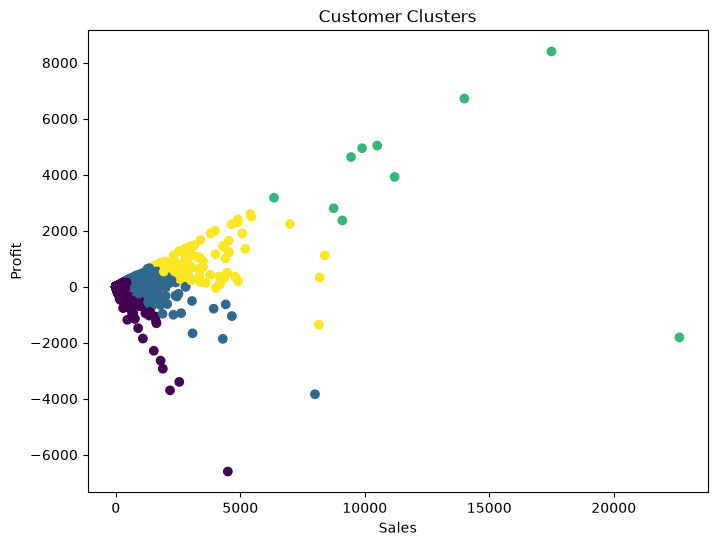

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(df["Sales"],df["Profit"],c=df["Cluster"])

plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Customer Clusters")

plt.show()

In [16]:
X = df[["Discount"]]

y = df["Sales"]

In [17]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [19]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-99.57]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Discount']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,249.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [20]:
pred = model.predict(X_test)

pred[:10]

array([249.57508703, 229.66102896, 179.87588377, 229.66102896,
       229.66102896, 219.70399992, 229.66102896, 249.57508703,
       249.57508703, 249.57508703])

In [21]:
print("R2 Score =", r2_score(y_test, pred))

R2 Score = -0.002125711408292208


In [22]:
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("RMSE =", rmse)

RMSE = 501.53073069573725


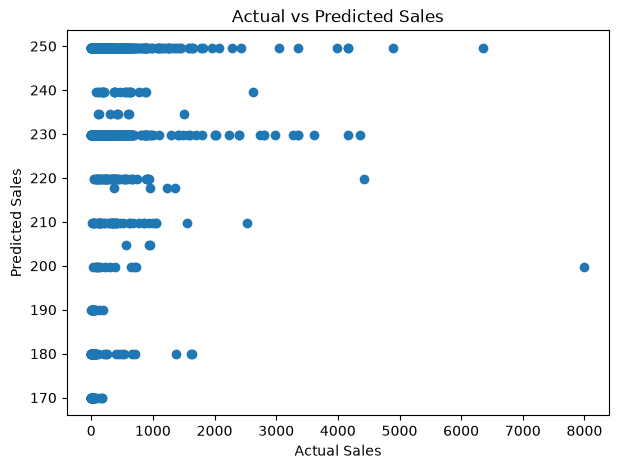

In [23]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [24]:
pred = model.predict(X_test)

print(pred[:10])

[249.57508703 229.66102896 179.87588377 229.66102896 229.66102896
 219.70399992 229.66102896 249.57508703 249.57508703 249.57508703]


In [25]:
print("R2 Score:", r2_score(y_test, pred))

R2 Score: -0.002125711408292208


In [26]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)

RMSE: 501.53073069573725


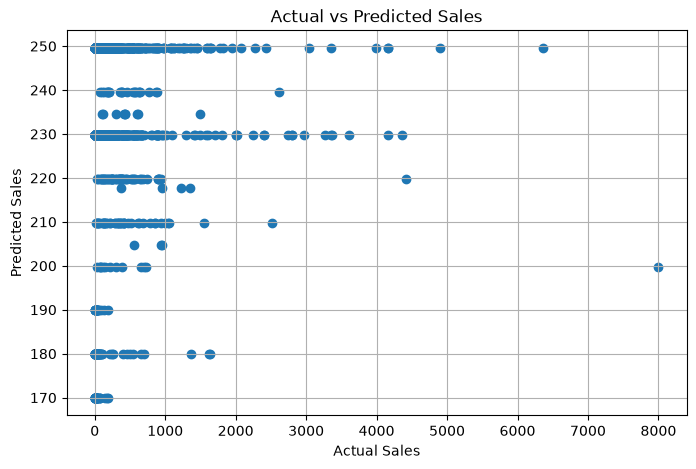

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.grid(True)

plt.show()

In [28]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Intercept: 249.57508703415417
Coefficient: [-99.57029038]


In [29]:
result = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": pred
})

result.head()

,Actual Sales,Predicted Sales
5825,29.980,249.575087
5171,53.248,229.661029
6041,16.146,179.875884
107,27.992,229.661029
3422,558.400,229.661029


In [30]:
result.to_csv("Prediction_Result.csv", index=False)

print("Prediction_Result.csv Saved Successfully")

Prediction_Result.csv Saved Successfully
